In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [12]:
data = pd.read_excel("../data/dataset_sailewoods.xlsx")
data.head()

,ID_Venta,fecha,producto,categoria,cantidad,precio_unitario,total_venta,metodo_pago,cliente_tipo,canal_venta,provincia
0,1,2024-05-05,Organizador de escritorio,Hogar,3,10.22,30.66,Transferencia,Nuevo,Tienda física,Azuay
1,2,2024-10-29,Organizador de escritorio,Hogar,1,18.81,18.81,Pago móvil,Nuevo,Tienda física,Tungurahua
2,3,2024-01-14,Cuchara de madera,Cocina,5,4.16,20.80,Transferencia,Frecuente,Instagram,Chimborazo
3,4,2024-03-22,Decoración de pared,Decoración,1,15.56,15.56,Pago móvil,Frecuente,WhatsApp,Pichincha
4,5,2024-02-22,Cuchara de madera,Cocina,3,7.79,23.37,Efectivo,Frecuente,Tienda física,Cotopaxi


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Venta         1000 non-null   int64  
 1   fecha            1000 non-null   str    
 2   producto         1000 non-null   str    
 3   categoria        1000 non-null   str    
 4   cantidad         1000 non-null   int64  
 5   precio_unitario  1000 non-null   float64
 6   total_venta      1000 non-null   float64
 7   metodo_pago      1000 non-null   str    
 8   cliente_tipo     1000 non-null   str    
 9   canal_venta      1000 non-null   str    
 10  provincia        1000 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 86.1 KB


In [14]:
data.columns = data.columns.str.lower()
data = data.dropna()
data.head()

,id_venta,fecha,producto,categoria,cantidad,precio_unitario,total_venta,metodo_pago,cliente_tipo,canal_venta,provincia
0,1,2024-05-05,Organizador de escritorio,Hogar,3,10.22,30.66,Transferencia,Nuevo,Tienda física,Azuay
1,2,2024-10-29,Organizador de escritorio,Hogar,1,18.81,18.81,Pago móvil,Nuevo,Tienda física,Tungurahua
2,3,2024-01-14,Cuchara de madera,Cocina,5,4.16,20.80,Transferencia,Frecuente,Instagram,Chimborazo
3,4,2024-03-22,Decoración de pared,Decoración,1,15.56,15.56,Pago móvil,Frecuente,WhatsApp,Pichincha
4,5,2024-02-22,Cuchara de madera,Cocina,3,7.79,23.37,Efectivo,Frecuente,Tienda física,Cotopaxi


In [15]:
data['total_venta'] = data['precio_unitario'] * data['cantidad']
data.head()

,id_venta,fecha,producto,categoria,cantidad,precio_unitario,total_venta,metodo_pago,cliente_tipo,canal_venta,provincia
0,1,2024-05-05,Organizador de escritorio,Hogar,3,10.22,30.66,Transferencia,Nuevo,Tienda física,Azuay
1,2,2024-10-29,Organizador de escritorio,Hogar,1,18.81,18.81,Pago móvil,Nuevo,Tienda física,Tungurahua
2,3,2024-01-14,Cuchara de madera,Cocina,5,4.16,20.80,Transferencia,Frecuente,Instagram,Chimborazo
3,4,2024-03-22,Decoración de pared,Decoración,1,15.56,15.56,Pago móvil,Frecuente,WhatsApp,Pichincha
4,5,2024-02-22,Cuchara de madera,Cocina,3,7.79,23.37,Efectivo,Frecuente,Tienda física,Cotopaxi


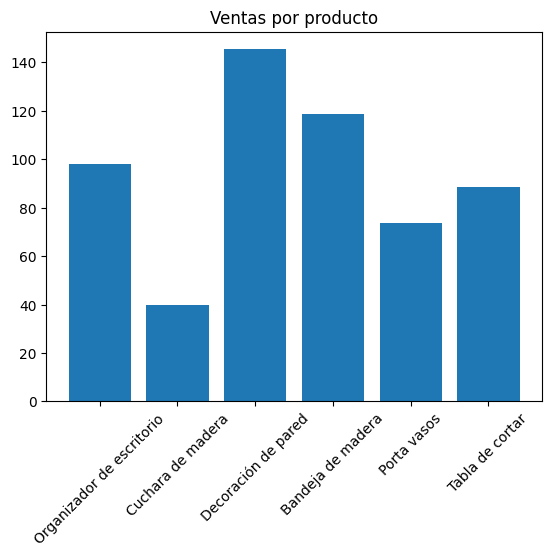

In [16]:
plt.figure()
plt.bar(data['producto'], data['total_venta'])
plt.xticks(rotation=45)
plt.title("Ventas por producto")
plt.show()

In [17]:
X = data[['precio_unitario', 'cantidad']]

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

data['cluster'] = kmeans.labels_
data.head()

,id_venta,fecha,producto,categoria,cantidad,precio_unitario,total_venta,metodo_pago,cliente_tipo,canal_venta,provincia,cluster
0,1,2024-05-05,Organizador de escritorio,Hogar,3,10.22,30.66,Transferencia,Nuevo,Tienda física,Azuay,2
1,2,2024-10-29,Organizador de escritorio,Hogar,1,18.81,18.81,Pago móvil,Nuevo,Tienda física,Tungurahua,0
2,3,2024-01-14,Cuchara de madera,Cocina,5,4.16,20.80,Transferencia,Frecuente,Instagram,Chimborazo,2
3,4,2024-03-22,Decoración de pared,Decoración,1,15.56,15.56,Pago móvil,Frecuente,WhatsApp,Pichincha,1
4,5,2024-02-22,Cuchara de madera,Cocina,3,7.79,23.37,Efectivo,Frecuente,Tienda física,Cotopaxi,2


In [18]:
data.groupby('cluster').__str__()

'<pandas.api.typing.DataFrameGroupBy object at 0x00000279BD115D10>'

## Análisis de resultados

Se aplicó el algoritmo K-Means para segmentar los productos.
Se identificaron 3 grupos:

- Cluster 0: productos de bajo precio y alta cantidad
- Cluster 1: productos de alto precio y baja demanda
- Cluster 2: productos equilibrados

Esto permite mejorar la toma de decisiones en producción.

# 📊 Análisis de Datos - SaileWood’s

**Autor:** Flavio Miguel Sailema  
**Asignatura:** Minería de Datos  

Este proyecto tiene como objetivo analizar los datos de ventas del emprendimiento SaileWood’s, con el fin de identificar patrones de compra y apoyar la toma de decisiones.

## 🧩 Problema

El emprendimiento SaileWood’s no cuenta con un análisis detallado de sus ventas, lo que dificulta la toma de decisiones estratégicas sobre producción, precios y productos más rentables.

Por ello, se aplica minería de datos para identificar patrones y comportamientos en las ventas.

## 🎯 Objetivo

Analizar los datos de ventas de SaileWood’s mediante técnicas de minería de datos para identificar patrones de comportamiento y segmentar los productos según su rendimiento.


## 📂 Carga de datos

En esta sección se carga el dataset en formato Excel, el cual contiene información sobre productos, precios y cantidades vendidas.

## 🔍 Análisis exploratorio de datos

Se realiza un análisis inicial para comprender la estructura del dataset, identificar valores nulos y observar el comportamiento de las variables.

Esto permite preparar los datos para el modelado.

## 🔧 Transformación de datos

Se crea una nueva variable llamada **ventas_totales**, que representa el ingreso generado por cada producto.

Esto se calcula multiplicando el precio por la cantidad vendida.

## 📊 Visualización de datos

Se genera un gráfico de barras para visualizar las ventas totales por producto, lo que permite identificar cuáles generan mayores ingresos.

## 🤖 Modelado con K-Means

Se aplica el algoritmo de clustering K-Means para agrupar los productos según su precio y cantidad vendida.

Esto permite identificar diferentes segmentos de productos con comportamientos similares.

## 📈 Resultados

El modelo permitió clasificar los productos en diferentes grupos (clusters), lo que facilita:

- Identificar productos más rentables
- Detectar productos de baja rotación
- Mejorar la toma de decisiones en producción

## ✅ Conclusiones

El análisis de datos permitió identificar patrones importantes en las ventas de SaileWood’s.

El uso de técnicas de minería de datos facilita la segmentación de productos y mejora la toma de decisiones estratégicas en el emprendimiento.